<a href="https://colab.research.google.com/github/olivetahonsu/Pytorch_tutorials/blob/main/Pytorch_Neural_Networks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Necessary imports
import torch
import torch.nn as nn
import torch.nn.functional as F

In [2]:
# Create a class that inherits nn.Module
class Model(nn.Module):
  # Input Layer (4 features)
  # Hidden Layer 1 -- numerous neurons
  # H2
  # Output Layer (3 classes of iris flowers)

  def __init__(self, input_f = 4, h1 = 8, h2 = 9, output_f = 3):
    super().__init__() # instantiate nn.Module
    self.fc1 = nn.Linear(input_f, h1)
    self.fc2 = nn.Linear(h1, h2)
    self.out = nn.Linear(h2, output_f)


  def forward(self, x):
    x = F.relu(self.fc1(x))
    x = F.relu(self.fc2(x))
    x = self.out(x)
    return x

In [3]:
# Set the a manual seed for randomisation
torch.manual_seed(41)

# Create an instance of the Model class
model = Model()

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [5]:
url = 'https://gist.githubusercontent.com/netj/8836201/raw/6f9306ad21398ea43cba4f7d537619d0e07d5ae3/iris.csv'
df = pd.read_csv(url)

In [6]:
df.tail()

,sepal.length,sepal.width,petal.length,petal.width,variety
145,6.7,3.0,5.2,2.3,Virginica
146,6.3,2.5,5.0,1.9,Virginica
147,6.5,3.0,5.2,2.0,Virginica
148,6.2,3.4,5.4,2.3,Virginica
149,5.9,3.0,5.1,1.8,Virginica


In [7]:
# Change the categorical column from strings to numbers.
df['variety'] = df['variety'].replace('Setosa', 0.0)
df['variety'] = df['variety'].replace('Versicolor', 1.0)
df['variety'] = df['variety'].replace('Virginica', 2.0)


/tmp/ipykernel_3557/2409173208.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['variety'] = df['variety'].replace('Virginica', 2.0)


In [8]:
# Print the result
df

,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,0.0
1,4.9,3.0,1.4,0.2,0.0
2,4.7,3.2,1.3,0.2,0.0
3,4.6,3.1,1.5,0.2,0.0
4,5.0,3.6,1.4,0.2,0.0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2.0
146,6.3,2.5,5.0,1.9,2.0
147,6.5,3.0,5.2,2.0,2.0
148,6.2,3.4,5.4,2.3,2.0


In [9]:
# Test Train Split! Set X, y

X = df.drop('variety', axis = 1)
y = df['variety']

In [10]:
# Convert to numpy arrays
X = X.values
y = y.values

In [11]:
# Import
from sklearn.model_selection import train_test_split

In [12]:
# Split for train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 41)

In [13]:
# Convert X features to float tensors
X_train = torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)

In [14]:
# Convert y label to long tensor
y_train = torch.LongTensor(y_train)
y_test = torch.LongTensor(y_test)

In [15]:
# Set criterion for model to measure the error
criterion = nn.CrossEntropyLoss()

# Choose and optimizer
optimizer = torch.optim.Adam(model.parameters(), lr = 0.01) # The lower the lr(learning rate), the longer the model trains.

In [16]:
# Train the model!

epochs = 120
losses = [] # To keep track of the loss

for i in range(epochs):
  y_pred = model.forward(X_train)
  loss = criterion(y_pred, y_train)
  losses.append(loss.detach().numpy())

  if i % 10 == 0:
    print(f'Epoch: {i} and Loss: {loss}')

  # Do some back propagation
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()


Epoch: 0 and Loss: 1.125203251838684
Epoch: 10 and Loss: 1.0097211599349976
Epoch: 20 and Loss: 0.8162347674369812
Epoch: 30 and Loss: 0.585993230342865
Epoch: 40 and Loss: 0.4003389775753021
Epoch: 50 and Loss: 0.26794716715812683
Epoch: 60 and Loss: 0.1796349585056305
Epoch: 70 and Loss: 0.12165623158216476
Epoch: 80 and Loss: 0.0860651507973671
Epoch: 90 and Loss: 0.06522614508867264
Epoch: 100 and Loss: 0.05286872014403343
Epoch: 110 and Loss: 0.04508011043071747


Text(0.5, 0, 'Epoch')

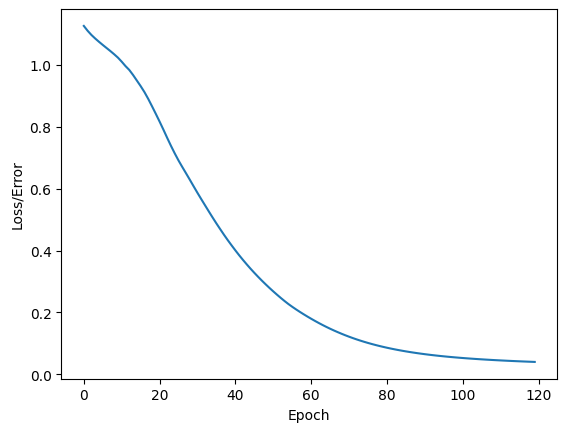

In [17]:
# Plot epochs and losses
plt.plot(range(epochs), losses)
plt.ylabel('Loss/Error')
plt.xlabel('Epoch')
# plt.show()

***- From the graph, what we want to see is a downward trend until it flattens out.***

***- If the graph does not flatten, we might need to increase the Epochs or reduce the learning rate (lr) or do both.***

In [18]:
# Evaluate the model
with torch.no_grad():
  y_eval = model.forward(X_test)
  loss = criterion(y_eval, y_test)

print(loss)

tensor(0.1296)


In [19]:
# Let's check which one is correct
correct = 0

with torch.no_grad():
  for i, data in enumerate(X_test):
    y_val = model.forward(data)

    if y_test[i] == 0.0:
      target = 'Setosa'
    elif y_test[i] == 1.0:
      target = 'Versicolor'
    else:
      target = 'Virginica'


    print(f'{i+1}.) \t {str(y_val)} \t {y_test[i]} \t {y_val.argmax().item()}')


    if y_val.argmax().item() == y_test[i]:
      correct += 1


print(f'\n We got {correct} out of {len(y_test)} = {100*correct/len(y_test):.2f}% correct')


1.) 	 tensor([-6.3770,  4.6260,  7.0910]) 	 2 	 2
2.) 	 tensor([-8.1968,  3.9870, 10.8910]) 	 2 	 2
3.) 	 tensor([-9.1794,  5.0753, 11.3389]) 	 2 	 2
4.) 	 tensor([-4.7218,  6.3277,  2.4014]) 	 1 	 1
5.) 	 tensor([-7.8080,  4.9407,  9.1663]) 	 2 	 2
6.) 	 tensor([-3.6908,  5.8963,  1.1680]) 	 1 	 1
7.) 	 tensor([-6.4402,  5.2674,  6.4765]) 	 2 	 2
8.) 	 tensor([-4.6753,  6.4189,  2.2212]) 	 1 	 1
9.) 	 tensor([-7.1081,  5.0998,  7.8016]) 	 2 	 2
10.) 	 tensor([-8.7514,  4.2196, 11.5782]) 	 2 	 2
11.) 	 tensor([-6.1758,  5.2599,  6.0477]) 	 2 	 2
12.) 	 tensor([ 4.8716, -2.4157, -3.1238]) 	 0 	 0
13.) 	 tensor([ 4.5424, -2.1538, -2.9456]) 	 0 	 0
14.) 	 tensor([-2.3022,  4.4610,  0.4685]) 	 1 	 1
15.) 	 tensor([ 3.6335, -1.2332, -2.5361]) 	 0 	 0
16.) 	 tensor([-5.9442,  5.5145,  5.3829]) 	 2 	 1
17.) 	 tensor([ 4.3267, -1.9296, -2.8674]) 	 0 	 0
18.) 	 tensor([-6.3089,  4.8115,  6.7813]) 	 1 	 2
19.) 	 tensor([ 5.3308, -2.8533, -3.3233]) 	 0 	 0
20.) 	 tensor([ 3.6467, -1.3062, -2.5448

In [20]:
# Let's try a new data point to test the model

new_iris = torch.tensor([3.2, 6.4, 3.6, 2.5])


with torch.no_grad():
  pred = model(new_iris)
  print(pred)

  flower = pred.argmax().item()

  if flower == 0:
    print('Setosa')
  elif flower == 1:
    print('Versicolor')
  else:
    print('Virginica')


tensor([-2.6129,  4.6700,  0.6959])
Versicolor


In [21]:
# Save the NN model
torch.save(model.state_dict(), 'my_iris_model.pt')

In [22]:
# Load the saved model
my_new_model = Model()
my_new_model.load_state_dict(torch.load('my_iris_model.pt'))

<All keys matched successfully>

In [23]:
# Let's make sure it is loaded correctly

my_new_model.eval()

Model(
  (fc1): Linear(in_features=4, out_features=8, bias=True)
  (fc2): Linear(in_features=8, out_features=9, bias=True)
  (out): Linear(in_features=9, out_features=3, bias=True)
)

In [24]:
# Test the loaded model
new_iris = torch.tensor([3.2, 6.4, 3.6, 2.5])

with torch.no_grad():
  pred = my_new_model(new_iris)
  print(pred)

tensor([-2.6129,  4.6700,  0.6959])
